<a href="https://colab.research.google.com/github/MuhammadAqsandy/scikit-learn-cookbook/blob/main/chapter_03_dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Dimensionality Reduction
## 📌 Summary
Dimensionality reduction menurunkan jumlah fitur sambil mempertahankan informasi penting. Teknik utama: **PCA** (unsupervised), **LDA** (supervised), **t-SNE** (visualisasi), dan **feature selection**.

## 🧠 Theoretical Deep-Dive

### 3.1 PCA (Principal Component Analysis)
PCA mencari **arah variansi maksimum** dalam data melalui eigendecomposition pada covariance matrix.

**Langkah PCA:**
1. Standardize data (penting!)
2. Compute covariance matrix: C = (1/n) XᵀX
3. Eigendecomposition: C·v = λ·v
4. Sort eigenvectors by eigenvalue (descending)
5. Project: X_new = X · W (W = matrix eigenvectors terpilih)

### 3.2 LDA (Linear Discriminant Analysis)
LDA adalah **supervised** reduction. Memaksimalkan **between-class scatter** (Sᴮ) dan meminimalkan **within-class scatter** (Sᵂ). Max komponen = n_classes - 1.

### 3.3 t-SNE
Non-linear, hanya untuk **visualisasi**. Tidak bisa digunakan untuk transform data baru.

### 3.4 Feature Selection
- **VarianceThreshold**: hapus low-variance features
- **SelectKBest**: statistical test (F-score, chi2, mutual info)
- **RFE**: recursive elimination berdasarkan model importance

## 💻 Code Reproduction

Original shape: (150, 4)
Reduced shape: (150, 2)
Explained variance ratio: [0.73  0.229]
Total explained variance: 0.958


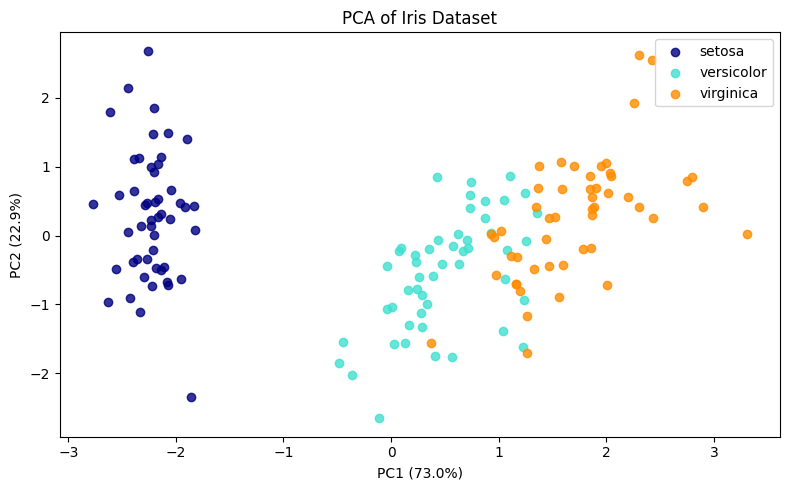

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

X, y = load_iris(return_X_y=True)
target_names = ["setosa", "versicolor", "virginica"]

X_std = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Total explained variance:", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(8, 5))
colors = ["navy", "turquoise", "darkorange"]
for color, i, label in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1], color=color, alpha=0.8, label=label)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.tight_layout()
plt.show()

Cumulative explained variance: [0.73  0.958 0.995 1.   ]


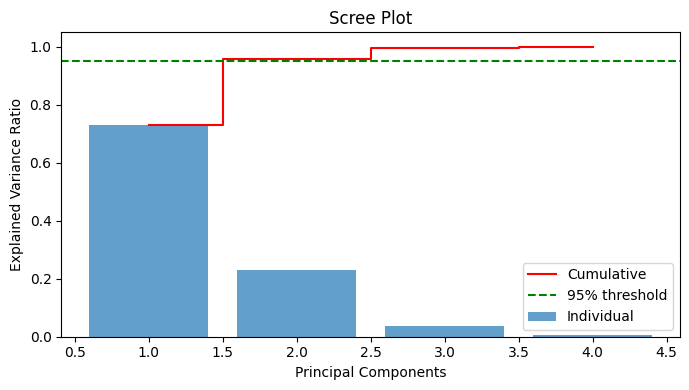

In [2]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X, _ = load_iris(return_X_y=True)
X_std = StandardScaler().fit_transform(X)

pca_full = PCA()
pca_full.fit(X_std)

cumvar = pca_full.explained_variance_ratio_.cumsum()
print("Cumulative explained variance:", cumvar.round(3))

plt.figure(figsize=(7, 4))
plt.bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.7, label="Individual")
plt.step(range(1, 5), cumvar, where="mid", color="red", label="Cumulative")
plt.axhline(0.95, linestyle="--", color="green", label="95% threshold")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.legend()
plt.tight_layout()
plt.show()

Original shape: (150, 4) → LDA shape: (150, 2)
Explained variance ratio: [0.991 0.009]


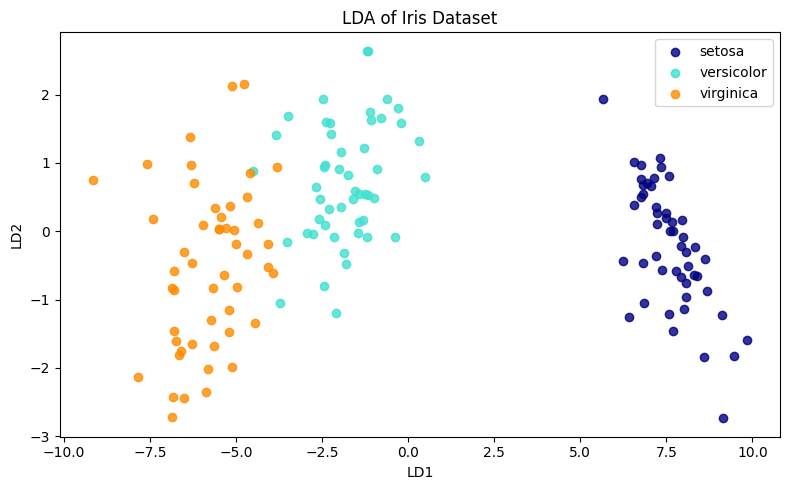

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)
target_names = ["setosa", "versicolor", "virginica"]

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

print("Original shape:", X.shape, "→ LDA shape:", X_lda.shape)
print("Explained variance ratio:", lda.explained_variance_ratio_.round(3))

plt.figure(figsize=(8, 5))
colors = ["navy", "turquoise", "darkorange"]
for color, i, label in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_lda[y==i, 0], X_lda[y==i, 1], color=color, alpha=0.8, label=label)
plt.xlabel("LD1"); plt.ylabel("LD2")
plt.title("LDA of Iris Dataset")
plt.legend(); plt.tight_layout()
plt.show()

Digits shape: (1797, 64)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


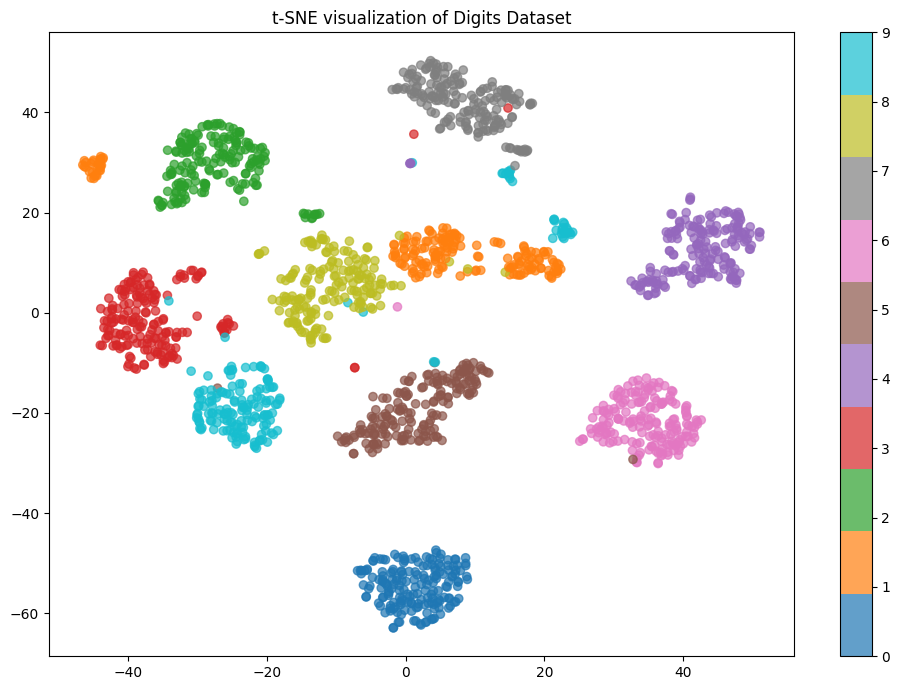

In [4]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

X, y = load_digits(return_X_y=True)
print("Digits shape:", X.shape)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", alpha=0.7)
plt.colorbar(scatter)
plt.title("t-SNE visualization of Digits Dataset")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

vt = VarianceThreshold(threshold=0.2)
X_vt = vt.fit_transform(X)
print("VarianceThreshold:", X.shape, "→", X_vt.shape)
print("Selected:", vt.get_support())

skb = SelectKBest(score_func=f_classif, k=2)
X_skb = skb.fit_transform(X, y)
print("\nSelectKBest (k=2):", X.shape, "→", X_skb.shape)
print("F-scores:", skb.scores_.round(2))

rfe = RFE(estimator=LogisticRegression(max_iter=200), n_features_to_select=2)
rfe.fit(X, y)
print("\nRFE selected:", rfe.support_)
print("Feature ranking:", rfe.ranking_)

VarianceThreshold: (150, 4) → (150, 3)
Selected: [ True False  True  True]

SelectKBest (k=2): (150, 4) → (150, 2)
F-scores: [ 119.26   49.16 1180.16  960.01]

RFE selected: [False False  True  True]
Feature ranking: [3 2 1 1]


## ✅ Chapter Summary
- **PCA**: unsupervised, linear → kompresi data & noise reduction
- **LDA**: supervised, linear → maximize class separation (max n_classes-1 komponen)
- **t-SNE**: non-linear → hanya untuk visualisasi
- Selalu **standardize** sebelum PCA/LDA
- **SelectKBest + RFE** → feature selection untuk meningkatkan interpretability & efisiensi